In [34]:
from scipy.integrate import solve_ivp
import numpy as np
import sympy as sm
from sympy import * 
import sympy.physics.mechanics as me
from sympy.physics.mechanics import *
import copy

Note: Including quadratic damping force.


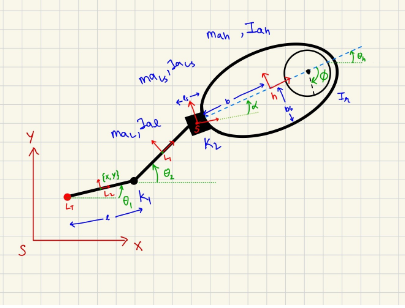


#### 1. Setup state variables and functions dependent on time

In [35]:
me.init_vprinting(use_latex='mathjax')
nl = 2
ns = 3+nl
nu = 2
q1, q2, q3, q4, q5 = me.dynamicsymbols('x, y, theta_1, theta_2, theta_h')
t = me.dynamicsymbols._t
alpha, phi = me.dynamicsymbols('alpha, phi')
q = sm.Matrix([q1, q2, q3, q4, q5])
inp = sm.Matrix([alpha, phi])
inp_d = inp.diff(t)
inp_dd = inp_d.diff(t)
oinput = sm.Matrix([inp,inp_d,inp_dd])
qd = q.diff(t)
qdd = qd.diff(t)
q, qd, qdd, inp, inp_d, inp_dd

⎛⎡x ⎤  ⎡ẋ ⎤  ⎡ẍ ⎤               ⎞
⎜⎢  ⎥  ⎢  ⎥  ⎢  ⎥               ⎟
⎜⎢y ⎥  ⎢ẏ ⎥  ⎢ÿ ⎥               ⎟
⎜⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎡α⎤  ⎡α̇⎤  ⎡α̈⎤⎟
⎜⎢θ₁⎥, ⎢θ₁̇⎥, ⎢θ₁̈⎥, ⎢ ⎥, ⎢ ⎥, ⎢ ⎥⎟
⎜⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎣φ⎦  ⎣φ̇⎦  ⎣φ̈⎦⎟
⎜⎢θ₂⎥  ⎢θ₂̇⎥  ⎢θ₂̈⎥               ⎟
⎜⎢  ⎥  ⎢  ⎥  ⎢  ⎥               ⎟
⎝⎣θₕ⎦  ⎣θₕ̇⎦  ⎣θₕ̈⎦               ⎠

##### 2. Setup Constants

In [36]:
l1, l2, ls, b, c = sm.symbols('l1, l2, ls, b, c')
K_1, K_2 = sm.symbols(' K_1, K_2')
ma_l1x, ma_l1y, ma_l2x, ma_l2y, ma_hx, ma_hy, ma_lsx, ma_lsy = sm.symbols('ma_l1x, ma_l1y, ma_l2x, ma_l2y, ma_hx, ma_hy, ma_lsx, ma_lsy')
Ia_h, Ia_l1, Ia_l2, Ia_ls, I_r= sm.symbols('Ia_h, Ia_l1, Ia_l2, Ia_ls, I_r')
C_hx, C_hy, C_lx, C_ly, C_wl, C_wh = sm.symbols('C_hx, C_hy, C_lx, C_ly, C_wl, C_wh')

Length = sm.Matrix([l1, l2, ls, b, c])
Stiffness = sm.Matrix([ K_1, K_2])
AddedMass = sm.Matrix([ma_l1x, ma_l1y, ma_l2x, ma_l2y,
                        ma_hx, ma_hy, ma_lsx, ma_lsy])
AddedInertia = sm.Matrix([Ia_h, Ia_l1, Ia_l2, Ia_ls, I_r])
Dissipation = sm.Matrix([C_hx, C_hy, C_lx, C_ly, C_wl, C_wh])
Const = sm.Matrix.vstack(Length, AddedMass, AddedInertia,
                          Dissipation, Stiffness).transpose()
Const_tuple = tuple(Const.tolist()[0])
Const_tuple

(l₁, l₂, ls, b, c, maₗ₁ₓ, ma_l1y, maₗ₂ₓ, ma_l2y, maₕₓ, ma_hy, maₗₛₓ, ma_lsy, I ↪

↪ aₕ, Iaₗ₁, Iaₗ₂, Iaₗₛ, Iᵣ, Cₕₓ, C_hy, Cₗₓ, C_ly, C_wl, C_wh, K₁, K₂)

#### 3. Positions, Jacobians and velocities for each body COM

In [37]:
# COM Positions (World frame)
# Link_1 (COM assumed at base point)
r_l1 = sm.Matrix([q[0],q[1]])

# Link_2 COM (+/- 0.5*l1, 0.5*l2)
r_l2 = r_l1 + sm.Matrix([0.5*l1*cos(q[2]) + 0.5*l2*cos(q[3]), 
                         0.5*l1*sin(q[2]) + 0.5*l2*sin(q[3])])

# Short Link COM (l2 full + 0.5*ls at angle (S(5,1)+alpha))
r_ls = r_l2 + sm.Matrix([0.5*l2*cos(q[3]) + 0.5*ls*cos(q[4] + inp[0]),
                         0.5*l2*sin(q[3]) + 0.5*ls*sin(q[4] + inp[0])])

# Head COM (ls full at (S(5,1)+alpha) + b at S(5,1))
r_h  = r_ls + sm.Matrix([0.5*ls*cos(q[4] + inp[0]) + b*cos(q[4]),
                         0.5*ls*sin(q[4] + inp[0]) + b*sin(q[4])])

# Jacobians wrt q (2x5) and alpha direction (2x1)
Jq1 = r_l1.jacobian(q)
ja1 = sm.diff(r_l1,inp[0])
Jq2 = r_l2.jacobian(q)
ja2 = sm.diff(r_l2,inp[0])
Jq3 = r_ls.jacobian(q)
ja3 = sm.diff(r_ls,inp[0])
Jq4 = r_h.jacobian(q)
ja4 = sm.diff(r_h,inp[0])

# Point velocities (WORLD) = Jq*qd + (Ja*d_alpha)

v_l1 = sm.simplify(Jq1*qd + ja1*inp[0]) # ja1 is zero
v_l2 = sm.simplify(Jq2*qd + ja2*inp[0]) # ja2 is zero
v_ls = sm.simplify(Jq3*qd + ja3*inp[0]) # depends on d_alpha
v_h  = sm.simplify(Jq4*qd + ja4*inp[0]) # depends on d_alpha

#### 4. Lagrangian

In [38]:
# Energy
# Diagonal mass matrices
ms_l1 = sm.diag(ma_l1x, ma_l1y)
ms_l2 = sm.diag(ma_l2x, ma_l2y)
ms_ls = sm.diag(ma_lsx, ma_lsy)
ms    = sm.diag(ma_hx,  ma_hy)

# Kinetic energy terms
T1 = 0.5* (v_l1.T * ms_l1 * v_l1)
T2 = 0.5 * (v_l2.T * ms_l2 * v_l2)
T3 = 0.5 * (v_ls.T * ms_ls * v_ls)
T4 = 0.5 * (v_h.T  * ms    * v_h)

# Total kinetic energy
TE = sm.simplify(T1[0] + T2[0] + T3[0] + T4[0])

## for rotational KE
RE = (0.5*Ia_l1*(qd[2]**2) + 0.5*Ia_l2*(qd[3]**2) + 
       0.5*Ia_ls*((qd[4]+inp_d[0])**2) + 0.5*Ia_h*(qd[4]**2) + 
       0.5*I_r*((qd[4]+inp_d[1])**2)) # rotational KE

## Conservative forces (Torsional smring Tail Bending))
PE = 0.5*K_1*(q[2]-q[3])**2 + 0.5*K_2*(q[3]-inp[0]-q[4])**2

## Lagrangian 
L = TE + RE - PE  # Lagrangian

#### 5. Substituting the dx and dy in the Lagrangian

In [39]:
# xd, xdd, yd, ydd = me.dynamicsymbols('xd, xdd, yd, ydd')
u = me.dynamicsymbols('u')
xd = u*sm.cos(q[2])-0.5*l1*qd[2]*sm.sin(q[2])
yd = u*sm.sin(q[2])+0.5*l1*qd[2]*sm.cos(q[2])
xdd = xd.diff(t)
ydd = yd.diff(t)
# [[xd], [yd], [xdd], [ydd]]

#### 6. Generalized Forces

##### 6a) non holonomic constraint

In [40]:
# nc = -sm.sin(q[2])*qd[0] + sm.cos(q[2])*qd[1] - 0.5*l1*qd[2]
nc = sm.Matrix([-sm.sin(q[2]), 
                 sm.cos(q[2]),  
                 -0.5*l1, 0, 0])

##### 6b) Quadratic damping forces (NO Rayleigh) + Quadratic rotational damping

In [41]:

# Rotation matrix function
def Rbw(th):
    return sm.Matrix([[sm.cos(th), sm.sin(th)],
                      [-sm.sin(th), sm.cos(th)]])

def Rwb(th):
    return Rbw(th).T


# Small smoothing term (exact symbolic value)
eps_v = sm.Float(1e-6)

# Smooth absolute value: ~|z|
def abs_s(z):
    return sm.sqrt(z**2 + eps_v)

# --- Velocities in body frame
vb_l1 = Rbw(q[2])*v_l1
vb_l2 = Rbw(q[3])*v_l2
vb_ls = Rbw(inp[0] + q[4])*v_ls
vb_h = Rbw(q[4])*v_h

C_l = sm.Matrix([[C_lx, 0],
                  [0, C_ly]])
C_h = sm.Matrix([[C_hx, 0],
                  [0, C_hy]])

# --- Quadratic drag in BODY frame (componentwise) ---
Fbl1 = -C_l * vb_l1.applyfunc(lambda z: abs_s(z) * z)
Fbl2 = -C_l * vb_l2.applyfunc(lambda z: abs_s(z) * z)
Fbls = -C_l * vb_ls.applyfunc(lambda z: abs_s(z) * z)
Fbh  = -C_h * vb_h.applyfunc(lambda z: abs_s(z) * z)

# --- Back to WORLD frame forces ---
Fwl1 = Rwb(q[2]) * Fbl1
Fwl2 = Rwb(q[3]) * Fbl2
Fwls = Rwb(q[4] + inp[0]) * Fbls
Fwh  = Rwb(q[4]) * Fbh

# --- Generalized forces from translational drag ---
Q_l1 = Jq1.T * Fwl1
Q_l2 = Jq2.T * Fwl2
Q_ls = Jq3.T * Fwls
Q_h  = Jq4.T * Fwh

Q_trans = sm.simplify(Q_l1 + Q_l2 + Q_ls + Q_h)

Q_rot = sm.zeros(ns, 1)
Q_rot[2] = -C_wl * abs_s(qd[2]) * qd[2]
Q_rot[3] = -C_wl * abs_s(qd[3]) * qd[3]
# No rotational drag for short link (as in your comment)
Q_rot[4] = -C_wh * abs_s(qd[4]) * qd[4]

# --- Total damping generalized force ---
Q_dq = sm.simplify(Q_trans + Q_rot)

#### 7. Euler-Lagrange equations

In [42]:
Eqn = sm.zeros(ns,1)
lam_1 = sm.symbols('lambda')
for i in range(ns):
    Eqn[i] = (diff(diff(L, qd[i]), t) - diff(L, q[i]) 
              - Q_dq[i] - nc[i]*lam_1)

Eqn1 = Eqn.subs({qdd[0]:xdd, qdd[1]:ydd})
Eqn2 = Eqn1.subs({qd[0]:xd, qd[1]:yd})

#####  7a) Solve for lambda and reduce EOM

In [43]:
eq_lam = Eqn2[0]*sm.sin(q[2]) - Eqn2[1]*sm.cos(q[2])
lam =  simplify(expand(-eq_lam+lam_1))
Eq1 = Eqn2[0]*sm.cos(q[2]) + Eqn2[1]*sm.sin(q[2])
Eq1 = expand(Eq1)
Eq1 = simplify(Eq1)
Eq2 = Eqn2[2].subs(lam_1,lam)
Eom = sm.Matrix([Eq1, Eq2, Eqn2[3], Eqn2[4]])

##### 7b) E.O.M by extracting Mass matrix, gravitational, coriollis and centrifugal terms


In [44]:
qr_dd = sm.Matrix([diff(u,t), qdd[2], qdd[3], qdd[4]])
qr_d = sm.Matrix([u, qd[2], qd[3], qd[4]])
u_repl = dict(zip(qr_d, zeros(4,1)))
qr_dd_zero = {qr_di: 0 for qr_di in qr_dd}

qdd, qr_dd_zero, u_repl
Ms = sm.simplify(Eom.jacobian(qr_dd))
B = Eom.xreplace(qr_dd_zero)
G = sm.simplify(B.xreplace(u_repl))
Cn_Qd = simplify(B-G)

#### 8. Function creation

In [45]:
sts = (u, qd[2], q[2], qd[3], q[3], qd[4], q[4])
inputs = (inp[0], inp_d[0], inp_dd[0], inp_dd[1])
# Create functions
eom_func = sm.lambdify((sts, inputs, Const_tuple), 
                       (Ms,Cn_Qd,G), modules="numpy")

In [46]:
from sympy.printing.pycode import pycode
from sympy.utilities.lambdify import lambdastr

s1, s2, s3, s4, s5, s6, s7 = sm.symbols('s1, s2, s3, s4, s5, s6, s7') # state variables 
sts_sym = (s1, s2, s3, s4, s5, s6, s7)
al, d_al, dd_al, ph, d_ph, dd_ph = sm.symbols('al, d_al, dd_al, ph, d_ph, dd_ph')
input_sym = (al, d_al, dd_al, dd_ph)
sts_repl = dict(zip(sts, sts_sym))
inputs_repl = dict(zip(inputs, input_sym))
Ms_sym = Ms.xreplace(sts_repl).xreplace(inputs_repl)
Cn_sym = Cn_Qd.xreplace(sts_repl).xreplace(inputs_repl)
G_sym = G.xreplace(sts_repl).xreplace(inputs_repl)
Ms_sym, Cn_sym, G_sym = sm.simplify(Ms_sym), sm.simplify(Cn_sym), sm.simplify(G_sym)

In [47]:

# Create output file
with open("CS_4link_RL.py", "w") as f:
    f.write("import numpy as np\n\n")

    def write_func(name, expr,sts_arg,input_arg,const_arg):
        # Make a flattened list of all inputs
        all_args = list(sts_arg) + list(input_arg) + list(const_arg)  # use tuple you created earlier
        # Convert expression to string-form function body
        code_str = lambdastr(all_args, expr)
        # Write to file with np.array wrapping if it's a matrix
        f.write(f"def {name}({', '.join(str(arg) for arg in all_args)}):\n")
        code_lines = code_str.split("return ")[-1]
        if expr.shape:  # matrix
            f.write(f"    return np.array({code_lines}, dtype=float)\n\n")
        else:
            f.write(f"    return {code_lines}\n\n")

    # Write the functions
    write_func("mass_matrix", Ms_sym,sts_sym,input_sym,Const_tuple)
    write_func("coriolis_matrix", Cn_sym,sts_sym,input_sym,Const_tuple)
    write_func("gravity_vector", G_sym,sts_sym,input_sym,Const_tuple)

In [48]:
# import numpy as np
# # ## Parameters for the Chaplygin Sleigh with servo actuated 3-link tail
# rho = 997   # density
# AM = 1.0  # activate added mass coefficient

# # For Head link 
# b1 = 0.075                                                       # length major axis (m)
# bs = 0.035                                                      # length minor axis (m)
# m_h = 0.44                                                      # mass (kg)
# I_h = m_h * (b1**2 + bs**2) / 4                                  # m.o.i (Kg/m^2) 
# ma_hx1 = m_h + AM*np.pi*rho * (bs**2 )* b1                        # added mass (kg)
# ma_hy1 = m_h + AM*np.pi * rho * (b1)**3                           # added mass (kg)
# Ia_h1 = I_h + AM*(1/8) * np.pi * rho * b1 * (b1**2 - bs**2)**2    # added m.o.i (Kg/m^2)

# # For link1 
# l11 = 0.048                                                      # length (m)
# m_l1 = 0.01 / 2                                                 # mass (kg)
# I_l1 = (1/12) * m_l1 * l11**2                                    # m.o.i (Kg/m^2)                                                   
# ma_l1x1 = m_l1 + AM*0                                                   # added mass (kg)
# ma_l1y1 = m_l1 + AM*np.pi * rho * 0.075 * (l11 / 2)**2            # added mass (kg)
# Ia_l11 = I_l1 + AM*(1/8) * np.pi * rho * 0.075 * (l11 / 2)**4    # added m.o.i (Kg/m^2)

# # For link2 
# l21 = 0.048                                                      # length (m)
# m_l2 = 0.01 / 2                                                 # mass (kg)
# I_l2 = (1/12) * m_l2 * l21**2                                    # m.o.i (Kg/m^2)                                                    
# ma_l2x1 = m_l2 + AM*0                                                   # added mass (kg)
# ma_l2y1 = m_l2 + AM*np.pi * rho * 0.075 * (l21 / 2)**2            # added mass (kg)
# Ia_l21 = I_l2 + AM*(1/8) * np.pi * rho * 0.075 * (l21 / 2)**4    # added m.o.i (Kg/m^2)

# # For short link 
# ls1 = 0.015                                                      # length (m)
# m_ls = 0.01                                                     # mass (kg)
# I_ls = (1/12) * m_ls * ls1**2                                    # m.o.i (Kg/m^2) 
# ma_lsx1 = m_ls + AM*0                                                    # added mass (kg)
# ma_lsy1 = m_ls + AM*np.pi * rho * 0.075 * (ls1 / 2)**2            # added mass (kg)
# Ia_ls1 = I_ls + AM*(1/8) * np.pi * rho * 0.075 * (ls1 / 2)**4    # added m.o.i (Kg/m^2)

# # For rotor 
# c1 = 0.03                                   # length (m)
# m_r = 0.1                                  # mass (kg)
# I_r1 = m_r * 0.027**2                        # m.o.i (Kg/m^2) 

# # Constant Rayleigh dissipation 
# C_hx1 = 0.46
# C_hy1 = 10
# C_lx1 = 0
# C_ly1 = 10
# K_11 = 0.4           # stiffness (Nm/rad)
# K_21 = 0.7           # stiffness (Nm/rad)

# Length = (l11, l21, ls1, b1, c1)
# Stiffness = ( K_11, K_21)
# AddedMass = (ma_l1x1, ma_l1y1, ma_l2x1, ma_l2y1, ma_hx1, ma_hy1, ma_lsx1, ma_lsy1)
# AddedInertia = (Ia_h1, Ia_l11, Ia_l21, Ia_ls1, I_r1)
# Dissipation = (C_hx1, C_hy1, C_lx1, C_ly1)
# Const1 = (*Length, *AddedMass, *AddedInertia, *Dissipation, *Stiffness)
# Const1
# Length = sm.Matrix([l11, l21, ls1, b1, c1])
# Stiffness = sm.Matrix([ K_11, K_21])
# AddedMass = sm.Matrix([ma_l1x1, ma_l1y1, ma_l2x1, ma_l2y1, ma_hx1, ma_hy1, ma_lsx1, ma_lsy1])
# AddedInertia = sm.Matrix([Ia_h1, Ia_l11, Ia_l21, Ia_ls1, I_r1])
# Dissipation = sm.Matrix([C_hx1, C_hy1, C_lx1, C_ly1])
# Const1 = sm.Matrix.vstack(Length, AddedMass, AddedInertia, Dissipation, Stiffness).transpose()
# Const_tuple1 = tuple(Const1.tolist()[0])

# st_replu = sm.Matrix([u, qd[2], q[2], qd[3], q[3], qd[4], q[4], inp[0], inp_d[0], inp_dd[0], inp_dd[1]])
# nm_replu = sm.Matrix([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1])
# replu = dict(zip(st_replu, nm_replu))
# repl = dict(zip(Const_tuple, Const_tuple1))
# MM = Ms.xreplace(replu).xreplace(repl)
# MCn_Qd = Cn_Qd.xreplace(replu).xreplace(repl)
# MG = G.xreplace(replu).xreplace(repl)

# MM, MCn_Qd, MG

# sts3 = [0.1, 2, 0.3, 0.04, 0.5, 0.6, 0.7]     # (u, qd[2], q[2], ...)
# inputs3 = [0.8, 0.9, 1, 100.1]                 # (inp[0], inp_d[0], ...)
# Mst,Cnt,Gt = eom_func(sts3, inputs3, Const_tuple1)

# # Mst = np.array(Mst).reshape(-1, nb-2, nb-2)
# # q = np.array([sts3[0], sts3[1], sts3[3], sts3[5]]).reshape(-1, 1)
# # np.linalg.solve(Mst, -Cnt@q- Gt) # check if the system is consistent
# Mst, Cnt, Gt
# Mst = np.array(Mst, dtype=np.float64)
# Cnt = np.array(Cnt, dtype=np.float64)
# Gt  = np.array(Gt,  dtype=np.float64)
# -Cnt- Gt
# np.linalg.solve(Mst, -Cnt- Gt) # check if the system ins consistent

In [49]:
# from CS_4link_v1 import ChaplyginSleighModel

# # Example input values
# sts3 = [0.1, 2, 0.3, 0.04, 0.5, 0.6, 0.7]     # (u, qd[2], q[2], ...)
# inputs3 = [0.8, 0.9, 1, 100.1]                 # (inp[0], inp_d[0], ...)
# Const_vals = Const1  # Put all 29 constants here
# # Call the functions
# model = ChaplyginSleighModel(Const_vals)

# f = model.dynamics(sts3,inputs3)
# M = model.Ms(sts3,inputs3)
# C = model.C_qd(sts3,inputs3)
# G = model.G(sts3,inputs3)
# # f_val
# # Mst,Cnt,Gt = eom_func(sts3, inputs3, Const_vals)
# # np.linalg.solve(Mst, -Cnt@q- Gt)
# M, C, G